# 1. Setup

In [1]:
# !pip install "tabpfn-extensions[all] @ git+https://github.com/PriorLabs/tabpfn-extensions.git"

In [2]:
# Utilities
import time
import warnings
warnings.filterwarnings("ignore")

# Dataframe
import numpy as np
import pandas as pd

# ML: Sklearn
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)

# ML: TabPFN
from tabpfn import TabPFNClassifier

# ML: Torch
import torch

# ML: Optimization
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNClassifier

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.figure_factory as ff
import plotly.express as px

# Saving models
import joblib

print("Core libraries loaded.")

Core libraries loaded.


In [3]:
# Setting up the GPU
if torch.cuda.is_available():
    device = "cuda"
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    device = "cpu"
    print("Using CPU.")

GPU: NVIDIA GeForce RTX 3060 Ti


In [4]:
# Constants
random_state = 8 # Lucky Number
years = ["2020", "2021", "2022", "2024"]

features_const = ["ID", "SEX"]
features = ["AGE", "MARRIED", "CHILD", "HINCOME_group", "JOB_group",
            "Exercise", "HealthyDiet", "Activity", "Interaction_offline",
            "Interaction_online", "Altruistic", "Optimism", "HealthySleep",
            "DeteriorationEconomy", "DeteriorationInteract", "Frustration",
            "CovidAnxiety", "CovidSleepless", "Difficultyliving", "DifficultyWork"]
target = "LSNS_group"

features_LSNS = ["Sex_Male", "Age", "Is_Married", "Has_Child", "Income", "Income_Missing",
                 "Job_Employed", "Job_Homemaker", "Job_Student", "Job_Unemployed", "Job_Other",
                 "Activity", "Exercise", "Healthy_Diet", "Healthy_Sleep",
                 "Interaction_Offline", "Interaction_Online",
                 "Altruistic", "Frustration", "Optimism",
                 "Covid_Anxiety", "Covid_Sleepless", "Deterioration_Economy", "Deterioration_Interact",
                 "Difficulty_Living", "Difficulty_Work"]

target_LSNS = "Socially_Isolated"
class_names = ["Not isolated", "Isolated"] # index 0 and 1, respectively
vars_LSNS = ["ID", "Phase", "Year"]

In [5]:
# Utilities
def format_time(seconds):
    hrs = int(seconds // 3600)
    mins = int((seconds % 3600) // 60)
    secs = seconds % 60
    parts = []
    if hrs: parts.append(f"{hrs}h")
    if mins: parts.append(f"{mins}m")
    parts.append(f"{secs:.2f}s")
    return " ".join(parts)

# 2. Dataset Loading & Preprocessing

In [6]:
DATA_PATH = "../../data/dataset.csv"

df = pd.read_csv(DATA_PATH, na_values=["NA", "N/A", "NaN", "null", "NULL", "", " ", "-"])
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 2659 rows, 106 columns


,ID,SEX,AGE_1,MARRIED_1,CHILD_1,HINCOME_group_1,JOB_group_1,LSNS_group_1,K6_1,PHQ9_1,...,Altruistic_4,Optimism_4,HealthySleep_4,DeteriorationEconomy_4,DeteriorationInteract_4,Frustration_4,CovidAnxiety_4,CovidSleepless_4,Difficultyliving_4,DifficultyWork_4
0,1,1,53,2,2,4.0,1,1,3,8,...,5,4,4,4,3,3,5,5,5,5
1,2,2,66,2,2,5.0,2,0,1,0,...,7,7,7,1,1,1,5,1,1,6
2,3,1,48,1,1,3.0,1,1,3,6,...,1,3,5,4,1,1,1,1,1,1
3,4,1,62,2,2,5.0,1,1,0,0,...,1,5,5,1,1,1,1,1,1,1
4,5,1,59,2,2,5.0,1,0,1,6,...,2,5,5,4,4,4,4,2,4,4


In [7]:
# Reshape longitudinal data
df_prep_list = []
for i, year in enumerate(years, 1):
    current_features = [f"{col}_{i}" for col in features]
    current_target = [f"{col}_{i}" for col in [target]]
    cols_to_select = features_const + current_features + current_target
    temp_df = df[cols_to_select].copy()
    rename_mapping = {f"{col}_{i}": col for col in features + [target]}
    temp_df = temp_df.rename(columns=rename_mapping)
    temp_df["Phase"] = i
    temp_df["Year"] = year
    df_prep_list.append(temp_df)

df_prep = pd.concat(df_prep_list, ignore_index=True)
print(f"Reshaped: {df_prep.shape}")

Reshaped: (10636, 25)


In [8]:
# Handle missing data
missing_values = df_prep.isnull().sum()
missing_percent = 100 * df_prep.isnull().sum() / len(df_prep)
missing_df = pd.DataFrame({"Missing Count": missing_values, "Missing Percentage": missing_percent})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values(by="Missing Count", ascending=False)
if missing_df.empty:
    print("No missing values.")
else:
    display(missing_df)

,Missing Count,Missing Percentage
HINCOME_group,1860,17.487777


In [9]:
# Encode categorical features
df_encoded = df_prep.copy()
df_encoded["Sex_Male"] = (df_encoded["SEX"] == 1).astype(int)
df_encoded["Is_Married"] = (df_encoded["MARRIED"] == 2).astype(int)
df_encoded["Has_Child"] = (df_encoded["CHILD"] == 2).astype(int)
df_encoded["Income_Missing"] = df_encoded["HINCOME_group"].isna().astype(int)
df_encoded["Income"] = df_encoded["HINCOME_group"].fillna(0).astype(int)

job_map = {1: "Job_Employed", 2: "Job_Homemaker", 3: "Job_Student",
           4: "Job_Unemployed", 5: "Job_Other"}
job_labels = df_encoded["JOB_group"].astype("Int64").map(job_map)
job_encoding = pd.get_dummies(job_labels, dtype=int)
df_encoded = pd.concat([df_encoded, job_encoding], axis=1)

df_encoded = df_encoded.rename(columns={
    "AGE": "Age", "HealthyDiet": "Healthy_Diet", "HealthySleep": "Healthy_Sleep",
    "Interaction_offline": "Interaction_Offline", "Interaction_online": "Interaction_Online",
    "CovidAnxiety": "Covid_Anxiety", "CovidSleepless": "Covid_Sleepless",
    "DeteriorationEconomy": "Deterioration_Economy",
    "DeteriorationInteract": "Deterioration_Interact",
    "Difficultyliving": "Difficulty_Living", "DifficultyWork": "Difficulty_Work"
})

df_encoded[target_LSNS] = df_encoded["LSNS_group"].astype(int)
df_encoded = df_encoded.drop(columns=["SEX", "MARRIED", "CHILD", "HINCOME_group", "JOB_group"])
df_encoded = df_encoded[vars_LSNS + features_LSNS + [target_LSNS]]
dist = df_encoded[target_LSNS].value_counts().sort_index()
print(f"Not isolated (0): {dist[0]}  |  Isolated (1): {dist[1]}  "
      f"|  Prevalence: {dist[1] / dist.sum():.1%}")

Not isolated (0): 3894  |  Isolated (1): 6742  |  Prevalence: 63.4%


# 3. EDA

In [10]:
# Statistical
df_encoded.describe()

,ID,Phase,Sex_Male,Age,Is_Married,Has_Child,Income,Income_Missing,Job_Employed,Job_Homemaker,...,Altruistic,Frustration,Optimism,Covid_Anxiety,Covid_Sleepless,Deterioration_Economy,Deterioration_Interact,Difficulty_Living,Difficulty_Work,Socially_Isolated
count,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,...,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000
mean,1330.000000,2.500000,0.582926,53.791087,0.644321,0.570985,2.720666,0.174878,0.687759,0.139150,...,5.087909,3.031685,4.112354,3.291087,2.356149,3.493983,2.537890,2.646296,2.796822,0.633885
std,767.623216,1.118087,0.493099,12.784209,0.478741,0.494959,1.737744,0.379880,0.463430,0.346119,...,1.843496,1.683804,1.550914,1.686384,1.472101,1.702638,1.523418,1.641990,1.751135,0.481764
min,1.000000,1.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,665.000000,1.750000,0.000000,45.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,...,4.000000,1.000000,4.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000,0.000000
50%,1330.000000,2.500000,1.000000,54.000000,1.000000,1.000000,3.000000,0.000000,1.000000,0.000000,...,5.000000,3.000000,4.000000,4.000000,2.000000,4.000000,2.000000,2.000000,3.000000,1.000000
75%,1995.000000,3.250000,1.000000,63.000000,1.000000,1.000000,4.000000,0.000000,1.000000,0.000000,...,7.000000,4.000000,5.000000,5.000000,4.000000,4.000000,4.000000,4.000000,4.000000,1.000000
max,2659.000000,4.000000,1.000000,92.000000,1.000000,1.000000,5.000000,1.000000,1.000000,1.000000,...,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,1.000000


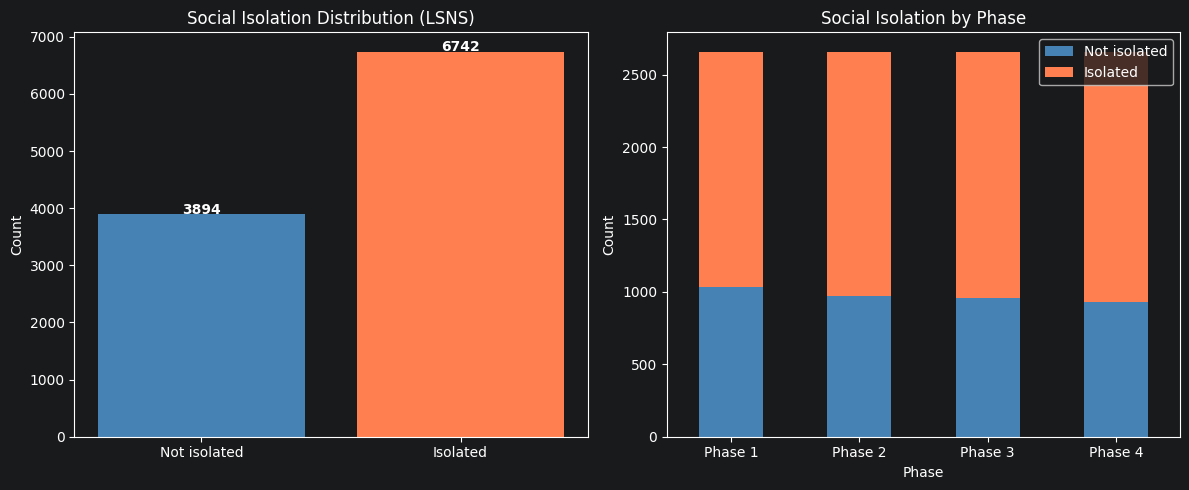

In [11]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df_encoded[target_LSNS].value_counts().sort_index()   # -> index [0, 1]
axes[0].bar(class_names, counts.values, color=["steelblue", "coral"])
axes[0].set_title("Social Isolation Distribution (LSNS)")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

phase_target = (df_encoded.groupby("Phase")[target_LSNS]
                .value_counts().unstack(fill_value=0)
                .reindex(columns=[0, 1], fill_value=0))
phase_target.plot(kind="bar", stacked=True, ax=axes[1], color=["steelblue", "coral"])
axes[1].set_title("Social Isolation by Phase")
axes[1].set_ylabel("Count")
axes[1].legend(class_names)
axes[1].set_xticklabels([f"Phase {i}" for i in phase_target.index], rotation=0)

plt.tight_layout()
plt.show()

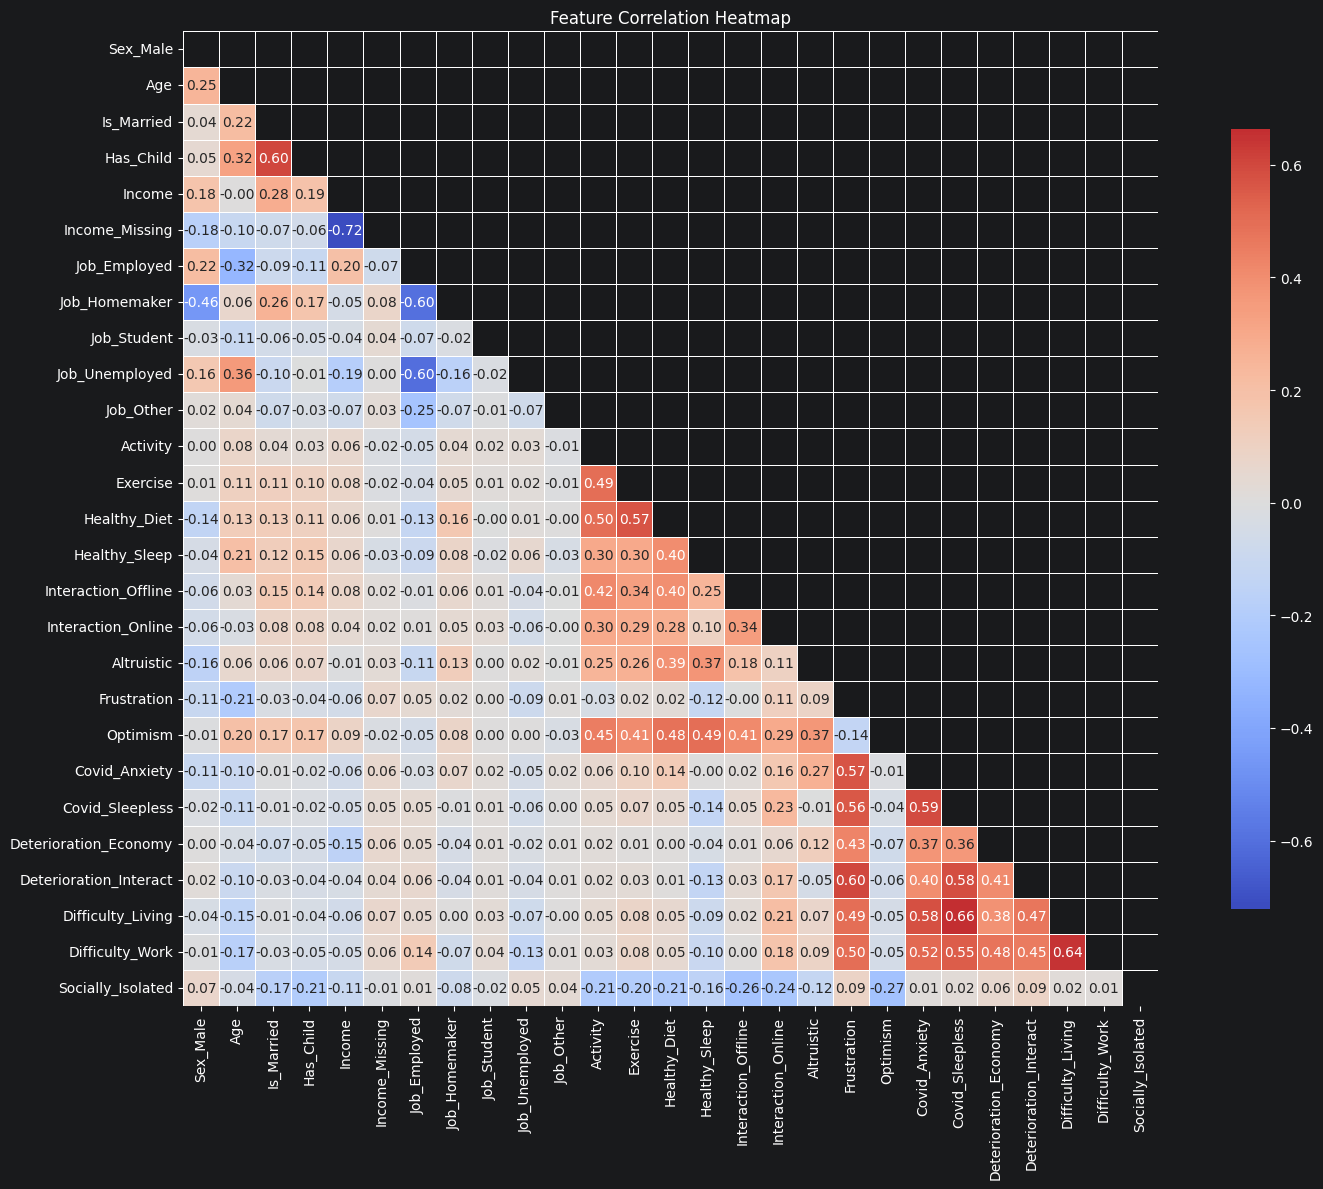

In [12]:
# Correlation heatmap
plt.figure(figsize=(16, 12))
corr = df_encoded[features_LSNS + [target_LSNS]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

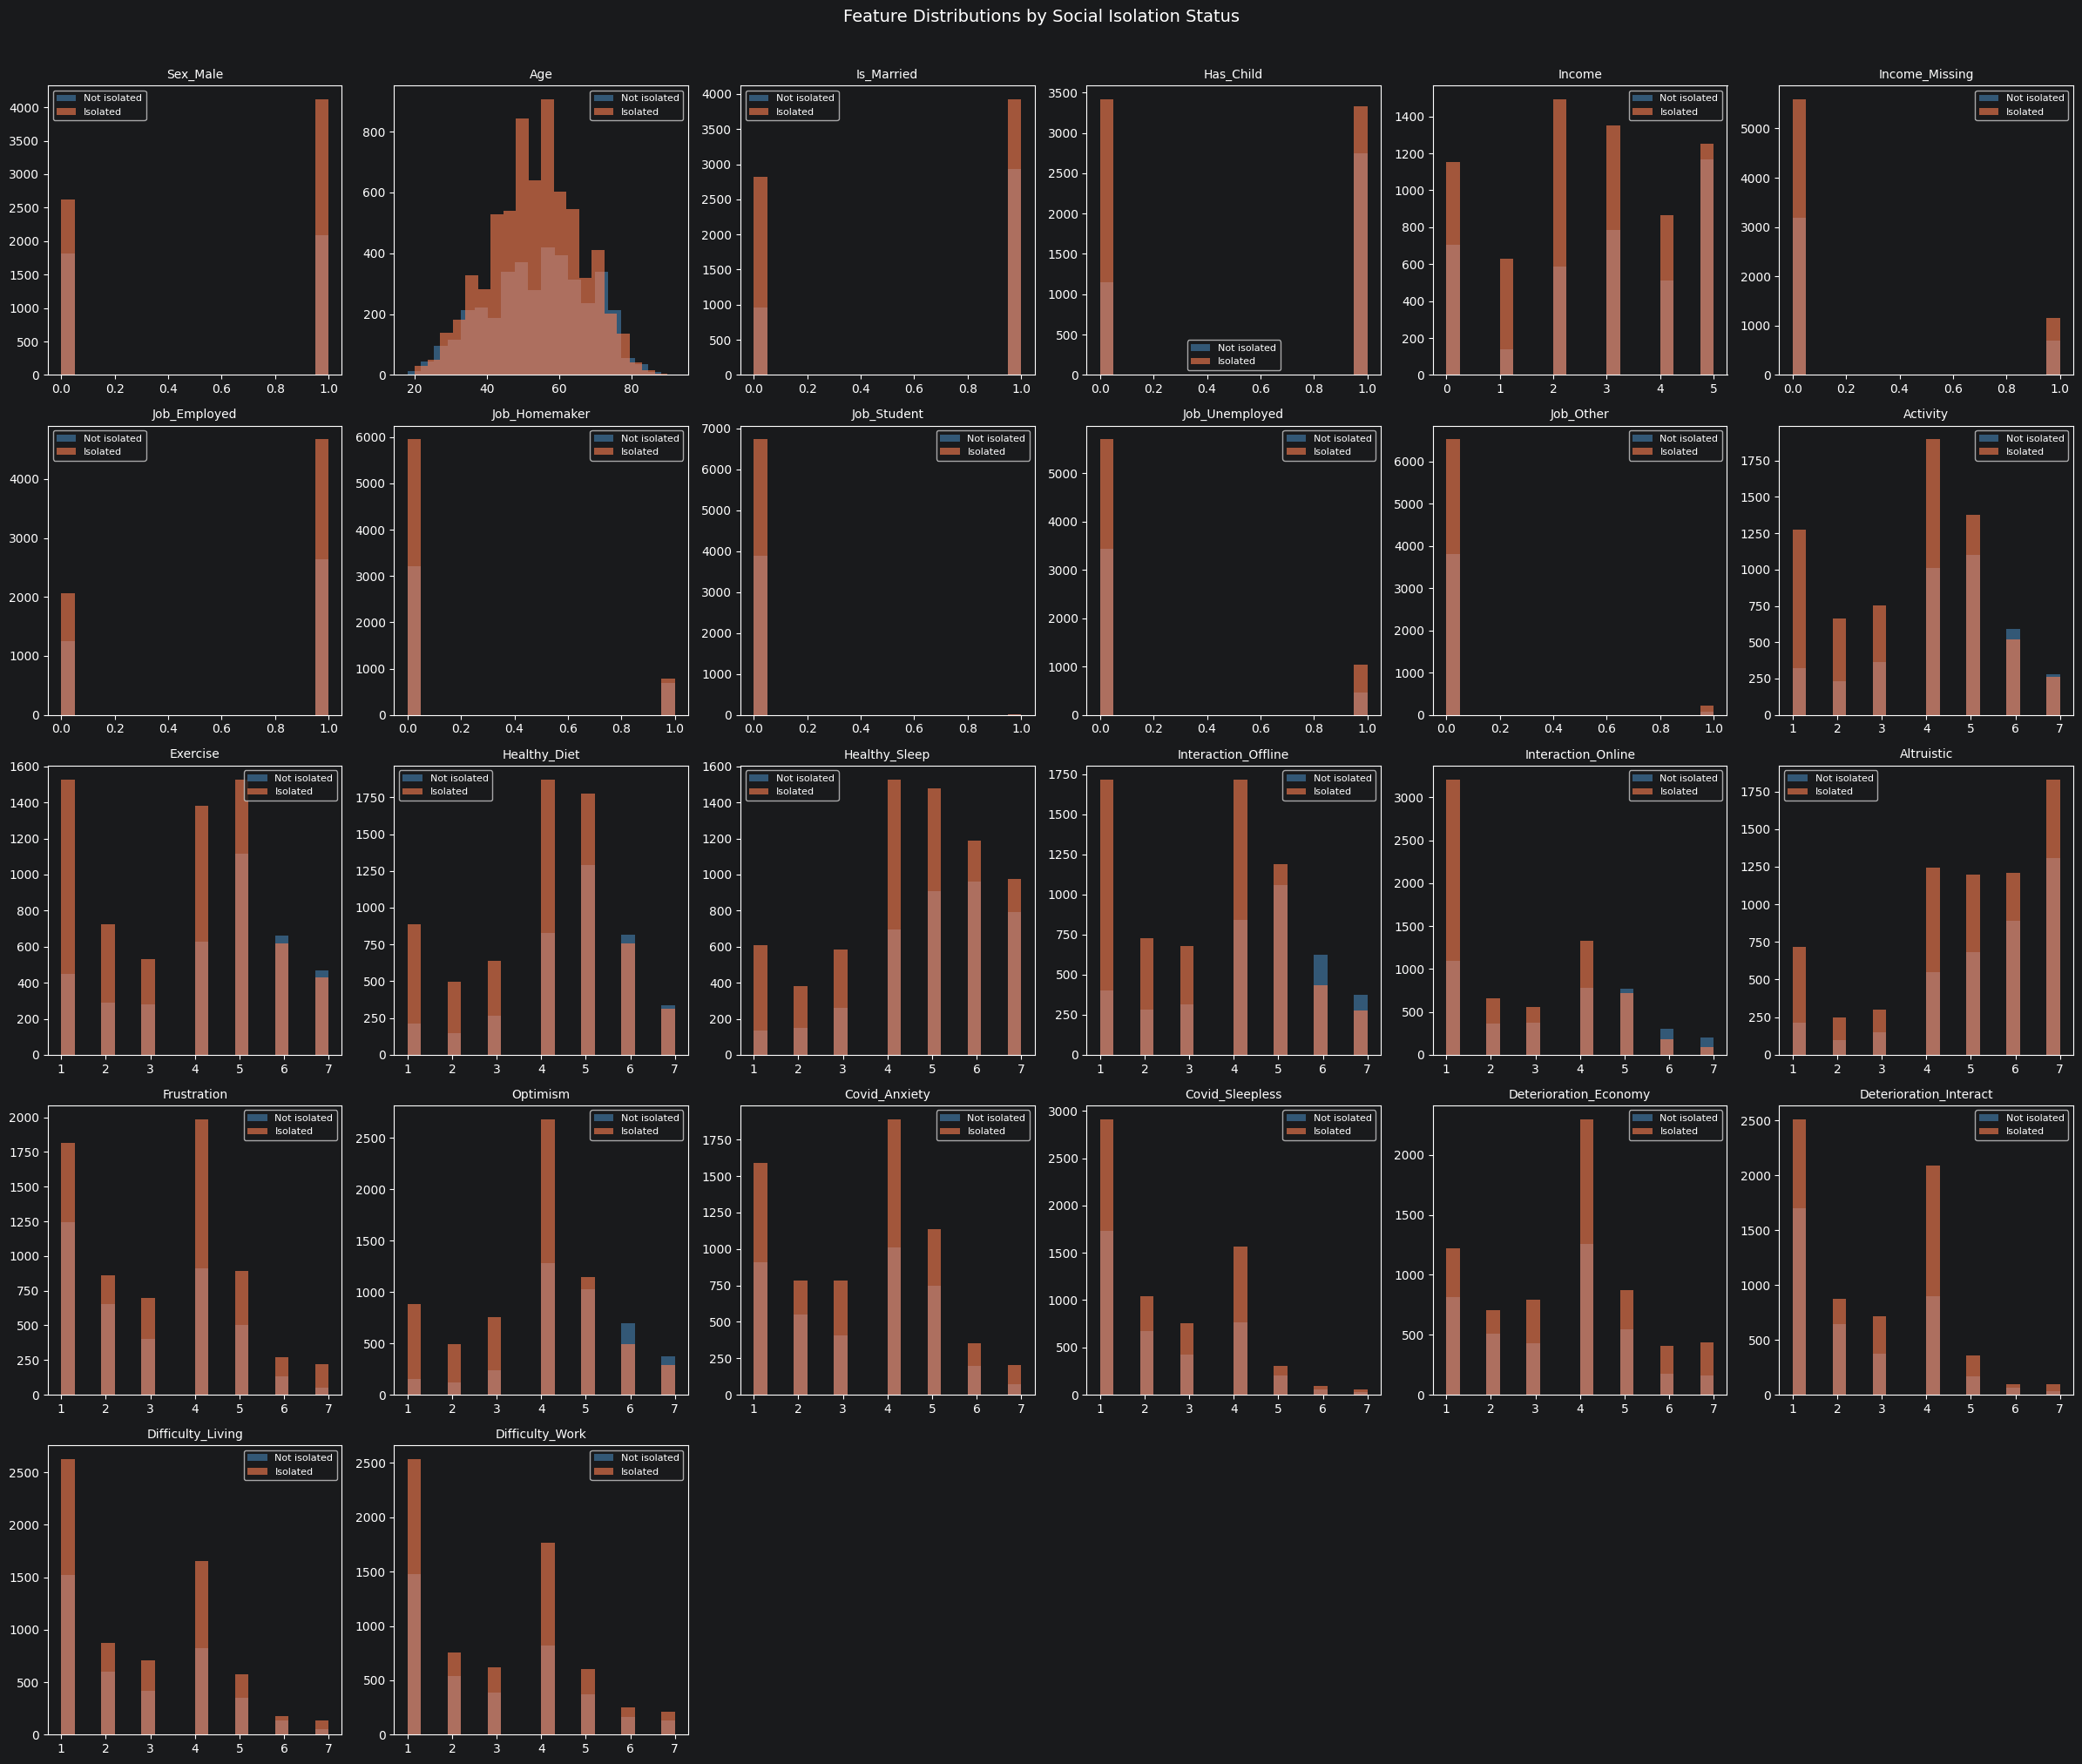

In [13]:
# Feature distributions by target class
fig, axes = plt.subplots(5, 6, figsize=(24, 20))
axes = axes.flatten()

for i, feat in enumerate(features_LSNS):
    if i < len(axes):
        for label, color in zip([0, 1], ["steelblue", "coral"]):
            subset = df_encoded[df_encoded[target_LSNS] == label][feat]
            axes[i].hist(subset, bins=20, alpha=0.6, color=color,
                         label=class_names[label])
        axes[i].set_title(feat, fontsize=10)
        axes[i].legend(fontsize=8)

for j in range(len(features_LSNS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions by Social Isolation Status", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 4. Train-Test Split

In [14]:
df_ml = df_encoded.copy()
df_train = df_ml[df_ml["Phase"].isin([1, 2, 3])].copy()
df_test = df_ml[df_ml["Phase"] == 4].copy()

ignore_feats = vars_LSNS
X_train = df_train.drop(columns=[target_LSNS] + ignore_feats, errors="ignore")
y_train = df_train[target_LSNS]
X_test = df_test.drop(columns=[target_LSNS] + ignore_feats, errors="ignore")
y_test = df_test[target_LSNS]

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Testing set:  {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")

Training set: 7977 samples, 26 features
Testing set:  2659 samples, 26 features

Training target distribution:
Socially_Isolated
1    5016
0    2961
Name: count, dtype: int64

Test target distribution:
Socially_Isolated
1    1726
0     933
Name: count, dtype: int64


# 5. Baseline Model Training

In [15]:
# Define all models with default hyperparameters
models = [
    ("TabPFN", TabPFNClassifier(device=device, random_state=random_state))
]

In [16]:
# Train and evaluate all baseline models
results = []
trained_models = {}
cm_data = {}

for name, model in models:
    print(f"\n{'='*60}")
    print(f"  {name} (baseline)")
    print(f"{'='*60}")

    # Train
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    # Predict
    start_test = time.time()
    y_pred = model.predict(X_test)
    test_time = time.time() - start_test

    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)   # 1 = isolated
    auc = roc_auc_score(y_test, y_prob)

    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC AUC:  {auc:.4f}")
    print(f"  Train:    {format_time(train_time)}")
    print(f"  Predict:  {format_time(test_time)}")
    print(f"\n{classification_report(y_test, y_pred, target_names=class_names)}")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1-Score": f1,
        "ROC AUC": auc,
        "Train Time (s)": train_time,
        "Test Time (s)": test_time
    })

    trained_models[name] = model
    cm_data[name] = confusion_matrix(y_test, y_pred)

df_results = pd.DataFrame(results)
print("\n" + "="*60)
print("  All baseline models trained.")
print("="*60)


  TabPFN (baseline)
  Accuracy: 0.7251
  F1-Score: 0.7962
  ROC AUC:  0.7689
  Train:    1.03s
  Predict:  8.62s

              precision    recall  f1-score   support

         Low       0.63      0.54      0.58       933
        High       0.77      0.83      0.80      1726

    accuracy                           0.73      2659
   macro avg       0.70      0.68      0.69      2659
weighted avg       0.72      0.73      0.72      2659


  All baseline models trained.


# 5. TabPFN Optimization

## 5.1 Feature Preprocessing Optimization

In [17]:
# Test different preprocessing strategies with TabPFN
preprocessing_results = []

# Strategy 1: No preprocessing (raw features)
print("Strategy 1: Raw features (baseline)")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
scores_raw = cross_val_score(
    TabPFNClassifier(device=device, random_state=random_state),
    X_train, y_train, cv=cv, scoring="f1", n_jobs=1
)
preprocessing_results.append({
    "Strategy": "Raw features",
    "Mean F1": scores_raw.mean(),
    "Std F1": scores_raw.std()
})
print(f"  CV F1: {scores_raw.mean():.4f} (+/- {scores_raw.std():.4f})")

# Strategy 2: StandardScaler
print("\nStrategy 2: StandardScaler")
from sklearn.pipeline import Pipeline
pipe_standard = Pipeline([
    ("scaler", StandardScaler()),
    ("tabpfn", TabPFNClassifier(device=device, random_state=random_state))
])
scores_standard = cross_val_score(pipe_standard, X_train, y_train, cv=cv, scoring="f1", n_jobs=1)
preprocessing_results.append({
    "Strategy": "StandardScaler",
    "Mean F1": scores_standard.mean(),
    "Std F1": scores_standard.std()
})
print(f"  CV F1: {scores_standard.mean():.4f} (+/- {scores_standard.std():.4f})")

# Strategy 3: MinMaxScaler
print("\nStrategy 3: MinMaxScaler")
from sklearn.preprocessing import MinMaxScaler
pipe_minmax = Pipeline([
    ("scaler", MinMaxScaler()),
    ("tabpfn", TabPFNClassifier(device=device, random_state=random_state))
])
scores_minmax = cross_val_score(pipe_minmax, X_train, y_train, cv=cv, scoring="f1", n_jobs=1)
preprocessing_results.append({
    "Strategy": "MinMaxScaler",
    "Mean F1": scores_minmax.mean(),
    "Std F1": scores_minmax.std()
})
print(f"  CV F1: {scores_minmax.mean():.4f} (+/- {scores_minmax.std():.4f})")

# Strategy 4: RobustScaler
print("\nStrategy 4: RobustScaler")
from sklearn.preprocessing import RobustScaler
pipe_robust = Pipeline([
    ("scaler", RobustScaler()),
    ("tabpfn", TabPFNClassifier(device=device, random_state=random_state))
])
scores_robust = cross_val_score(pipe_robust, X_train, y_train, cv=cv, scoring="f1", n_jobs=1)
preprocessing_results.append({
    "Strategy": "RobustScaler",
    "Mean F1": scores_robust.mean(),
    "Std F1": scores_robust.std()
})
print(f"  CV F1: {scores_robust.mean():.4f} (+/- {scores_robust.std():.4f})")

df_preproc = pd.DataFrame(preprocessing_results).sort_values("Mean F1", ascending=False)
print("\n=== Preprocessing Results ===")
display(df_preproc)

Strategy 1: Raw features (baseline)
  CV F1: 0.7830 (+/- 0.0065)

Strategy 2: StandardScaler
  CV F1: 0.7840 (+/- 0.0055)

Strategy 3: MinMaxScaler
  CV F1: 0.7835 (+/- 0.0076)

Strategy 4: RobustScaler
  CV F1: 0.7832 (+/- 0.0064)

=== Preprocessing Results ===


,Strategy,Mean F1,Std F1
1,StandardScaler,0.783980,0.005537
2,MinMaxScaler,0.783520,0.007601
3,RobustScaler,0.783187,0.006421
0,Raw features,0.783014,0.006451


In [18]:
# Visualize preprocessing comparison
fig = px.bar(df_preproc, x="Strategy", y="Mean F1", error_y="Std F1",
             title="TabPFN: Preprocessing Strategy Comparison (5-fold CV F1)",
             text_auto=".4f", color="Strategy")
fig.update_layout(yaxis_range=[0, 1], showlegend=False)
fig.show()

best_preproc = df_preproc.iloc[0]["Strategy"]
print(f"\nBest preprocessing: {best_preproc}")


Best preprocessing: StandardScaler


## 5.3 Train Final Optimized Model with Post-Hoc Ensembles
https://docs.priorlabs.ai/extensions/post-hoc-ensembles

In [19]:
# Build the best model based on optimization results
print("Training final optimized AutoTabPFN model...")
start_time = time.time()

# Select best preprocessing
scaler_map = {
    "Raw features": None,
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler(),
}

best_scaler = scaler_map.get(best_preproc)

if best_scaler is not None:
    X_train_opt = pd.DataFrame(
        best_scaler.fit_transform(X_train),
        columns=X_train.columns, index=X_train.index
    )
    X_test_opt = pd.DataFrame(
        best_scaler.transform(X_test),
        columns=X_test.columns, index=X_test.index
    )
else:
    X_train_opt = X_train.copy()
    X_test_opt = X_test.copy()

print(f"Using AutoTabPFN with max_time=60 and presets=medium_quality")

optimized_model = AutoTabPFNClassifier(
    device=device,
    max_time=60, # total search time in seconds
    presets="medium_quality", # or "best_quality"
    random_state=random_state
)

optimized_model.fit(X_train_opt, y_train)
opt_train_time = time.time() - start_time

print(f"Training time: {format_time(opt_train_time)}")

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.3
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #35~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Tue May 26 19:30:42 UTC 2
CPU Count:          12
Memory Avail:       22.02 GB / 31.25 GB (70.5%)
Disk Space Avail:   727.81 GB / 914.78 GB (79.6%)
Presets specified: ['medium_quality']


Training final optimized AutoTabPFN model...
Using AutoTabPFN with max_time=60 and presets=medium_quality


Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "/home/joaquin/PycharmProjects/xai-social-isolation/notebooks/experiments/3 - tabpfn_optimized/TabPFNModels/m-20260815_173640_244081"
Train Data Rows:    7977
Train Data Columns: 26
Label Column:       _target_
Problem Type:       TaskType.BINARY
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    22547.19 MB
	Train Data (Original)  Memory Usage: 1.58 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 9 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting Iden

Training time: 1m 1.44s


# 6. Results & Comparison

In [20]:
# Evaluate optimized model
y_pred_opt = optimized_model.predict(X_test_opt)
y_prob_opt = optimized_model.predict_proba(X_test_opt)[:, 1]

opt_acc = accuracy_score(y_test, y_pred_opt)
opt_f1 = f1_score(y_test, y_pred_opt, pos_label=1)   # 1 = isolated
opt_auc = roc_auc_score(y_test, y_prob_opt)

print(f"=== Optimized TabPFN Results ===")
print(f"Accuracy: {opt_acc:.4f}")
print(f"F1-Score: {opt_f1:.4f}")
print(f"ROC AUC:  {opt_auc:.4f}")
print(f"\n{classification_report(y_test, y_pred_opt, target_names=class_names)}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_opt)
fig_cm = ff.create_annotated_heatmap(
    z=cm.tolist(),
    x=["Predicted Not isolated", "Predicted Isolated"],
    y=["Actual Not isolated", "Actual Isolated"],
    annotation_text=[[str(y) for y in x] for x in cm.tolist()],
    colorscale="Viridis"
)
fig_cm.update_layout(title="Confusion Matrix: Optimized TabPFN", yaxis=dict(autorange="reversed"))
fig_cm.show()

=== Optimized TabPFN Results ===
Accuracy: 0.7198
F1-Score: 0.7927
ROC AUC:  0.7676

              precision    recall  f1-score   support

         Low       0.62      0.53      0.57       933
        High       0.76      0.83      0.79      1726

    accuracy                           0.72      2659
   macro avg       0.69      0.68      0.68      2659
weighted avg       0.71      0.72      0.71      2659



In [21]:
# Baseline vs Optimized comparison
comparison = pd.DataFrame([
    {"Model": "TabPFN (Baseline)", "Accuracy": acc, "F1-Score": f1, "ROC AUC": auc},
    {"Model": "TabPFN (Optimized)", "Accuracy": opt_acc, "F1-Score": opt_f1, "ROC AUC": opt_auc},
])
display(comparison)

df_cmp_melted = comparison.melt(id_vars="Model", value_vars=["Accuracy", "F1-Score", "ROC AUC"],
                                 var_name="Metric", value_name="Score")
fig = px.bar(df_cmp_melted, x="Metric", y="Score", color="Model", barmode="group",
             title="TabPFN: Baseline vs Optimized", text_auto=".4f")
fig.update_layout(yaxis_range=[0, 1])
fig.show()

print(f"\nF1 improvement:  {opt_f1 - f1:+.4f}")
print(f"AUC improvement: {opt_auc - auc:+.4f}")

,Model,Accuracy,F1-Score,ROC AUC
0,TabPFN (Baseline),0.725085,0.796209,0.768854
1,TabPFN (Optimized),0.719819,0.792652,0.767615



F1 improvement:  -0.0036
AUC improvement: -0.0012


In [22]:
# Inspect leaderboard
lb = optimized_model.predictor_.leaderboard(silent=True)
print(lb)

                 model  score_val eval_metric  pred_time_val   fit_time  \
0      TabPFNv2_BAG_L1   0.712549    accuracy      42.784077  44.906314   
1  WeightedEnsemble_L2   0.712549    accuracy      42.784987  44.908304   

   pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  \
0               42.784077          44.906314            1       True   
1                0.000910           0.001991            2       True   

   fit_order  
0          1  
1          2  


In [23]:
# Detailed info
optimized_model.predictor_.fit_summary()

*** Summary of fit() ***
Estimated performance of each model:
                 model  score_val eval_metric  pred_time_val   fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0      TabPFNv2_BAG_L1   0.712549    accuracy      42.784077  44.906314               42.784077          44.906314            1       True          1
1  WeightedEnsemble_L2   0.712549    accuracy      42.784987  44.908304                0.000910           0.001991            2       True          2
Number of models trained: 2
Types of models trained:
{'StackerEnsembleModel_TabPFNV2', 'WeightedEnsembleModel'}
Bagging used: True  (with 8 folds)
Multi-layer stack-ensembling used: False 
Feature Metadata (Processed):
(raw dtype, special dtypes):
('float', [])     : 17 | ['Age', 'Income', 'Activity', 'Exercise', 'Healthy_Diet', ...]
('int', ['bool']) :  9 | ['Sex_Male', 'Is_Married', 'Has_Child', 'Income_Missing', 'Job_Employed', ...]
*** End of fit() summary ***


{'model_types': {'TabPFNv2_BAG_L1': 'StackerEnsembleModel_TabPFNV2',
  'WeightedEnsemble_L2': 'WeightedEnsembleModel'},
 'model_performance': {'TabPFNv2_BAG_L1': 0.7125485771593331,
  'WeightedEnsemble_L2': 0.7125485771593331},
 'model_best': 'WeightedEnsemble_L2',
 'model_paths': {'TabPFNv2_BAG_L1': ['TabPFNv2_BAG_L1'],
  'WeightedEnsemble_L2': ['WeightedEnsemble_L2']},
 'model_fit_times': {'TabPFNv2_BAG_L1': 44.90631365776062,
  'WeightedEnsemble_L2': 0.0019905567169189453},
 'model_pred_times': {'TabPFNv2_BAG_L1': 42.784077167510986,
  'WeightedEnsemble_L2': 0.0009102821350097656},
 'num_bag_folds': 8,
 'max_stack_level': 2,
 'num_classes': 2,
 'model_hyperparams': {'TabPFNv2_BAG_L1': {'use_child_oof': False,
   'use_orig_features': True,
   'valid_stacker': True,
   'max_base_models': 0,
   'max_base_models_per_type': 'auto',
   'save_bag_folds': True,
   'stratify': 'auto',
   'bin': 'auto',
   'n_bins': None,
   'fold_fitting_strategy': 'sequential_local',
   'refit_folds': True}

# 7. Save Models & Results

In [24]:
# Save optimized model and scaler
joblib.dump(optimized_model, "models/tabpfn_optimized.joblib")
print("Optimized TabPFN model saved.")

if best_scaler is not None:
    joblib.dump(best_scaler, "models/tabpfn_optimized_scaler.joblib")
    print("Best scaler saved.")

Optimized TabPFN model saved.
Best scaler saved.


In [25]:
# Save training/test data
X_train_opt.to_csv("artifacts/X_train_opt.csv", index=False)
X_test_opt.to_csv("artifacts/X_test_opt.csv", index=False)
y_train.to_csv("artifacts/y_train.csv", index=False)
y_test.to_csv("artifacts/y_test.csv", index=False)